# Phase IV — Ensemble Methods
## Bank Marketing Dataset — ML Lab Project 2026

**Authors:** Arman Bazarchi, Ines Maria Madeira Prates

---

**Prerequisites:** Run `preprocessing.ipynb` first to generate the processed data in `data/`.

This notebook trains tree-based ensembles — **Random Forest** (bagging) and two **boosting** models
(AdaBoost, Gradient Boosting) — and compares them on three axes: **performance**, **training time**,
and **feature importance**. Unlike the kernel SVMs of Phase III, tree ensembles scale comfortably,
so here we train on the **full 33k** training set (no subsample), trees are also scale-invariant, so
the standardized features do no harm.

### Outline
1. Load Processed Data & Prepare Features
2. Baseline & Imbalance Handling
3. Train the Ensembles (Random Forest, AdaBoost, Gradient Boosting)
4. Comparison — Performance & Training Time
5. Feature Importance (permutation, TreeSHAP, grouped permutation)
6. Best Ensemble — Detailed Evaluation
7. Summary & Discussion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import train_test_split
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier)
from sklearn.dummy import DummyClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve, classification_report)

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## 1. Load Processed Data & Prepare Features

Same feature sets and split as Phases II-III so results are directly comparable: drop the leaky
`duration`, one-hot encode the categoricals, same 80/20 stratified split. Trees are scale-invariant
(they split on thresholds), so the standardized numerics are harmless, we keep them for a cleaner
comparison with the earlier phases.

In [2]:
X_scaled_df = pd.read_csv('data/X_scaled.csv')       # 15 standardized numeric features
cat_features = pd.read_csv('data/cat_features.csv')   # job, marital, month, day_of_week
y = pd.read_csv('data/y.csv')['y']

# Drop leaky 'duration'; one-hot the categoricals (drop_first avoids the dummy trap)
X_num = X_scaled_df.drop(columns=['duration'])
X_cat = pd.get_dummies(cat_features, drop_first=True).astype(int)
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Full design matrix: {X.shape}")
print(f"Train: {X_train.shape[0]} samples ({y_train.mean()*100:.2f}% positive)")
print(f"Test:  {X_test.shape[0]} samples ({y_test.mean()*100:.2f}% positive)")
print("Trees scale fine -> we train on the FULL training set (no subsample needed, unlike Phase III).")

Full design matrix: (41188, 41)
Train: 32950 samples (11.27% positive)
Test:  8238 samples (11.26% positive)
Trees scale fine -> we train on the FULL training set (no subsample needed, unlike Phase III).


---
## 2. Baseline & Imbalance Handling

We keep the same stratified dummy baseline, and address the 11% imbalance inside each model:
Random Forest supports `class_weight='balanced'`; AdaBoost / Gradient Boosting do not, so we pass
**balanced `sample_weight`** to their `fit` (the equivalent re-weighting).

In [3]:
dummy = DummyClassifier(strategy='stratified', random_state=42).fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_scores = dummy.predict_proba(X_test)[:, 1]
print("Baseline (stratified dummy):")
print(f"  Accuracy: {accuracy_score(y_test, dummy_pred):.4f}   F1: {f1_score(y_test, dummy_pred):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_test, dummy_scores):.4f}   AUPR: {average_precision_score(y_test, dummy_scores):.4f}")

# Balanced sample weights for the boosters (which lack a class_weight parameter)
sw_train = compute_sample_weight('balanced', y_train)
print(f"\nBalanced sample weights: minority rows up-weighted to {sw_train.max():.2f}, majority to {sw_train.min():.2f}")




Baseline (stratified dummy):
  Accuracy: 0.8037   F1: 0.1207
  ROC-AUC:  0.5051   AUPR: 0.1137

Balanced sample weights: minority rows up-weighted to 4.44, majority to 0.56


---
## 3. Train the Ensembles

- **Random Forest** (bagging): many deep trees on bootstrap samples, votes averaged → low variance.
- **AdaBoost** (boosting): sequential shallow stumps, each focusing on the previous errors.
- **Gradient Boosting** (boosting): sequential shallow trees fit to the gradient of the loss;
  `subsample=0.8` makes it stochastic (a little regularization).

We time each fit on the full 33k and evaluate on the test set with `predict_proba` for ROC-AUC/AUPR.

In [4]:
def eval_model(name, model, Xte, yte, fit_time=None):
    scores = model.predict_proba(Xte)[:, 1]
    pred = model.predict(Xte)
    return {'model': name,
            'accuracy': accuracy_score(yte, pred),
            'f1': f1_score(yte, pred),
            'roc_auc': roc_auc_score(yte, scores),
            'aupr': average_precision_score(yte, scores),
            'fit_time_s': fit_time}

models, rows = {}, []

# Random Forest (bagging) -- class_weight handles imbalance, OOB gives a free validation estimate
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight='balanced',
                            oob_score=True, n_jobs=-1, random_state=42)
t0 = time.perf_counter(); rf.fit(X_train, y_train); rf_t = time.perf_counter() - t0
models['Random Forest'] = rf

# AdaBoost (boosting) -- balanced sample weights given
ada = AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=42)
t0 = time.perf_counter(); ada.fit(X_train, y_train, sample_weight=sw_train); ada_t = time.perf_counter() - t0
models['AdaBoost'] = ada

# Gradient Boosting (boosting) -- balanced sample weights given, stochastic (subsample<1)
gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=3,
                                subsample=0.8, random_state=42)
t0 = time.perf_counter(); gb.fit(X_train, y_train, sample_weight=sw_train); gb_t = time.perf_counter() - t0
models['Gradient Boosting'] = gb

for (name, m), ft in zip(models.items(), [rf_t, ada_t, gb_t]):
    rows.append(eval_model(name, m, X_test, y_test, ft))
ens_df = pd.DataFrame(rows).set_index('model')

print("Ensembles trained on full 33k, evaluated on full test set:")
print(ens_df.round(4).to_string())
print(f"\nRandom Forest OOB accuracy (free validation): {rf.oob_score_:.4f}")

# All three ensembles PASS the ~0.79 ROC-AUC record that every linear/SVM model hit before:
# Gradient Boosting 0.811 and Random Forest 0.807, with AUPR ~0.48-0.49 (higher than ~0.43 before).
# This is the first REAL jump in this project -- trees capture the feature interactions more cleanly and
# threshold effects that linear/kernel models could not express.
#
# Random Forest shows best results: best F1 (0.52), best AUPR (0.486), best accuracy (0.872), and
# the FASTEST fit (~1.2s). Its OOB accuracy (0.864) closely tracks the held-out accuracy (0.872),
# which is a good sign that the model is well-calibrated and not overfit. 
# Gradient Boosting edges ROC-AUC (0.811 vs 0.807).

Ensembles trained on full 33k, evaluated on full test set:
                   accuracy      f1  roc_auc    aupr  fit_time_s
model                                                           
Random Forest        0.8724  0.5216   0.8073  0.4861      1.1687
AdaBoost             0.8358  0.4629   0.7974  0.4606      2.8762
Gradient Boosting    0.8394  0.4802   0.8107  0.4838      5.4593

Random Forest OOB accuracy (free validation): 0.8642


---
## 4. Comparison — Performance & Training Time

Performance & training time (full test set):
                   accuracy      f1  roc_auc    aupr  fit_time_s
model                                                           
Gradient Boosting    0.8394  0.4802   0.8107  0.4838      5.4593
Random Forest        0.8724  0.5216   0.8073  0.4861      1.1687
AdaBoost             0.8358  0.4629   0.7974  0.4606      2.8762
Baseline (dummy)     0.8037  0.1207   0.5051  0.1137         NaN


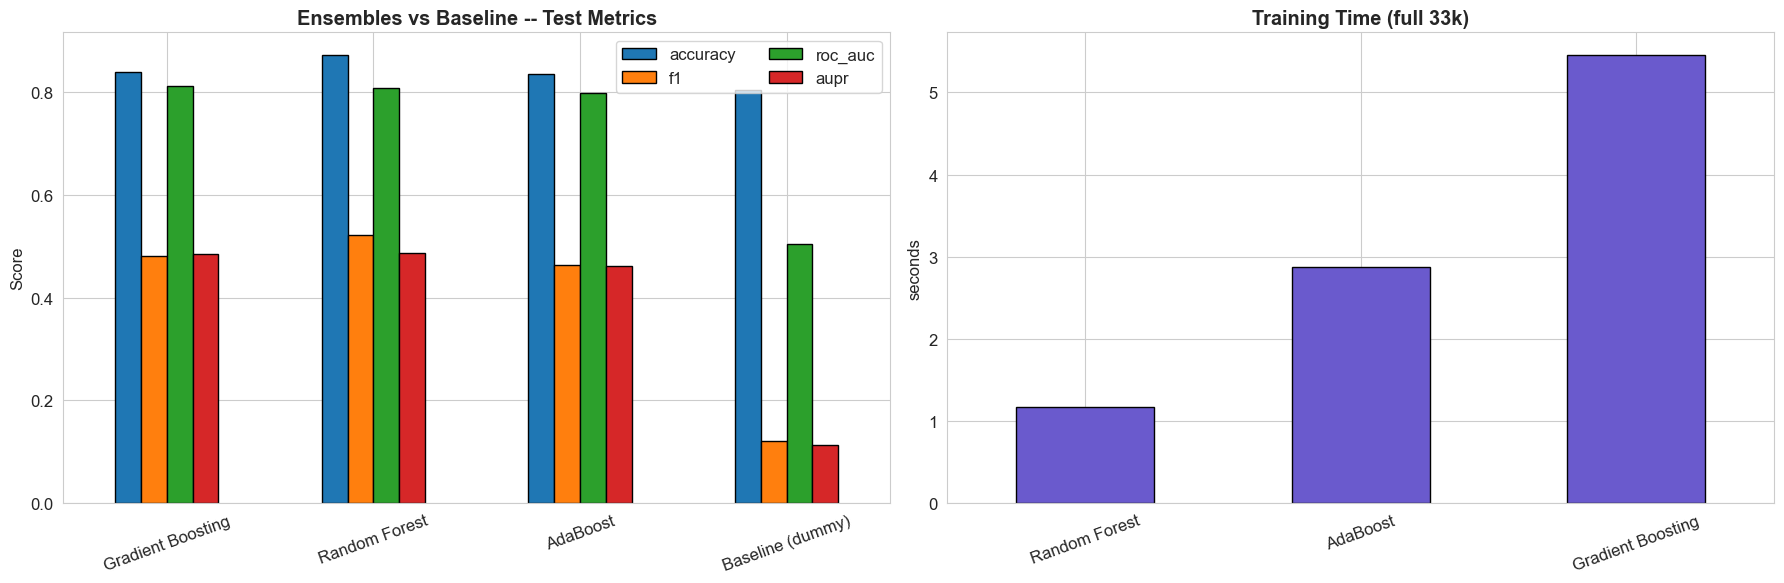

In [5]:
compare = ens_df.copy()
compare.loc['Baseline (dummy)'] = [accuracy_score(y_test, dummy_pred), f1_score(y_test, dummy_pred),
                                   roc_auc_score(y_test, dummy_scores),
                                   average_precision_score(y_test, dummy_scores), np.nan]
compare = compare.sort_values('roc_auc', ascending=False)
print("Performance & training time (full test set):")
print(compare.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
metric_df = compare[['accuracy', 'f1', 'roc_auc', 'aupr']]
metric_df.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Ensembles vs Baseline -- Test Metrics', fontweight='bold')
axes[0].set_ylabel('Score'); axes[0].set_xlabel(''); axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(loc='upper right', ncol=2)

ens_df['fit_time_s'].plot(kind='bar', ax=axes[1], color='slateblue', edgecolor='black')
axes[1].set_title('Training Time (full 33k)', fontweight='bold')
axes[1].set_ylabel('seconds'); axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# Gradient Boosting and Random Forest lead (ROC-AUC ~0.81, AUPR ~0.48), clearly above
# the Phase II logistic (0.797 / 0.428) and Phase III SVMs (~0.793 / ~0.43). The absolute gain is
# moderate (~+0.015 ROC-AUC, ~+0.05 AUPR) but it is the FIRST model family to break the overlap 
# record -- and the AUPR lift (which matters most under imbalance) is the largest in the project so far.
#
# It is effectively a TIE between RF and GB: GB edges ROC-AUC by 0.003 (within noise), while RF wins
# AUPR, F1 and accuracy. We therefore select RANDOM FOREST as the practical best (and it is also the
# fastest), and analyse it in sections 5-6.
#
# TRAINING TIME: the striking contrast with Phase III -- all three ensembles fit the FULL 33k in
# 1-5s (RF fastest ~1.2s thanks to parallel trees;) GB slowest ~5s because boosting is sequential),
# whereas the kernel SVMs with a 12k subsample and ~55s just for the linear grid. For this dataset
# the ensembles dominate on both generalization metrics and training speed.

---
## 5. Feature Importance

We assess importance with three methods, chosen for our data (which has a highly
collinear macro block, |r|>0.9):
- **Permutation importance** (test set): model-agnostic, shuffles one feature and measures the
  ROC-AUC drop. Trustworthy, but still UNDER-states correlated features.
- **Grouped permutation**: shuffles whole correlated *blocks* together, which removes permutation's
  collinearity blind spot — the cleanest attribution for our macro block.
- **TreeSHAP**: exact, fast Shapley values for tree ensembles — adds **direction** and per-client
  explanations, its the best standard for trees.


Permutation importance (Random Forest, ROC-AUC drop when shuffled, top 15):
emp.var.rate      0.0139
contact           0.0129
euribor3m         0.0116
nr.employed       0.0075
poutcome          0.0074
campaign          0.0029
month_may         0.0023
age               0.0022
cons.conf.idx     0.0019
previous          0.0017
cons.price.idx    0.0015
month_oct         0.0013
housing           0.0013
default           0.0013
month_nov         0.0011


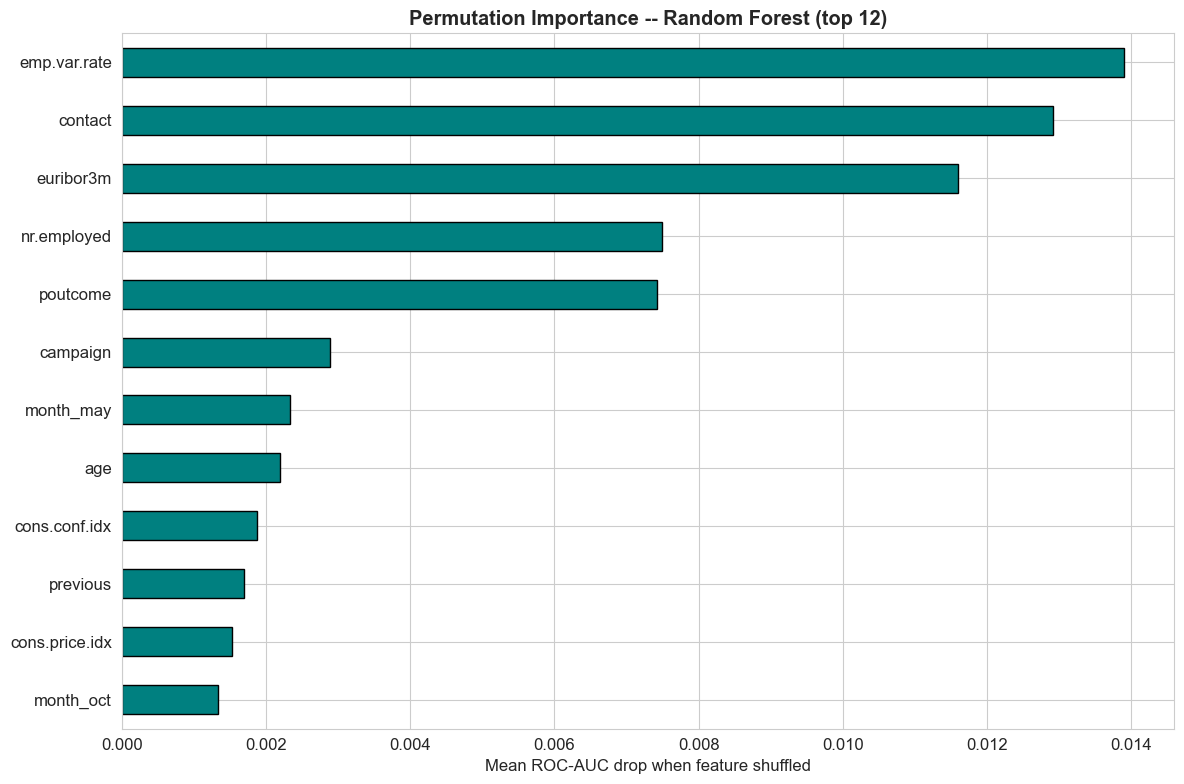

In [6]:
# We select Random Forest as the best/final ensemble. Gradient Boosting's
# ROC-AUC is marginally higher (0.811 vs 0.807, within noise), but RF is the more practical choice:
# it wins AUPR (0.486), F1 (0.52) and accuracy (0.872) and trains ~5x faster (1.2s vs 5.3s). For an
# imbalanced ranking task AUPR/F1 matter most, so we go with RF.
best_name = 'Random Forest'
best_model = models[best_name]

# Permutation importance on the test set (unbiased, scoring = ROC-AUC)
perm = permutation_importance(best_model, X_test, y_test, scoring='roc_auc',
                              n_repeats=10, n_jobs=-1, random_state=42)
perm_imp = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)

print(f"Permutation importance ({best_name}, ROC-AUC drop when shuffled, top 15):")
print(perm_imp.head(15).round(4).to_string())

perm_imp.head(12).iloc[::-1].plot(kind='barh', figsize=(12, 8), color='teal', edgecolor='black')
plt.title(f'Permutation Importance -- {best_name} (top 12)', fontweight='bold')
plt.xlabel('Mean ROC-AUC drop when feature shuffled'); plt.tight_layout()
plt.show()

# Permutation importance ranks emp.var.rate, contact, euribor3m, nr.employed and poutcome at the top,
# the same economy + campaign signal we have tracked since Phase I. 'age' sits near the bottom (~0.002),
# matching its weak r=0.03 from EDA (this is why we dropped the impurity method, which over-rated age
# purely because it is continuous).
#
# The absolute drops are small (~0.01-0.014) because Random Forest is highly redundant (bagging):
# removing any single feature barely hurts. This makes the
# single-feature UNDER-statement of correlated features even stronger, our macro block is
# collinear (|r|>0.9), so shuffling one macro feature alone hardly moves ROC-AUC. The grouped
# permutation below shuffles the whole block at once and reveals its true (much larger) importance.

Grouped permutation importance (Gradient Boosting, base ROC-AUC = 0.8107):
                     roc_auc_drop     std
group                                    
Economy (macro)            0.1922  0.0051
Campaign history           0.0382  0.0035
Month                      0.0075  0.0018
Client demographics        0.0015  0.0026
Day of week                0.0014  0.0011


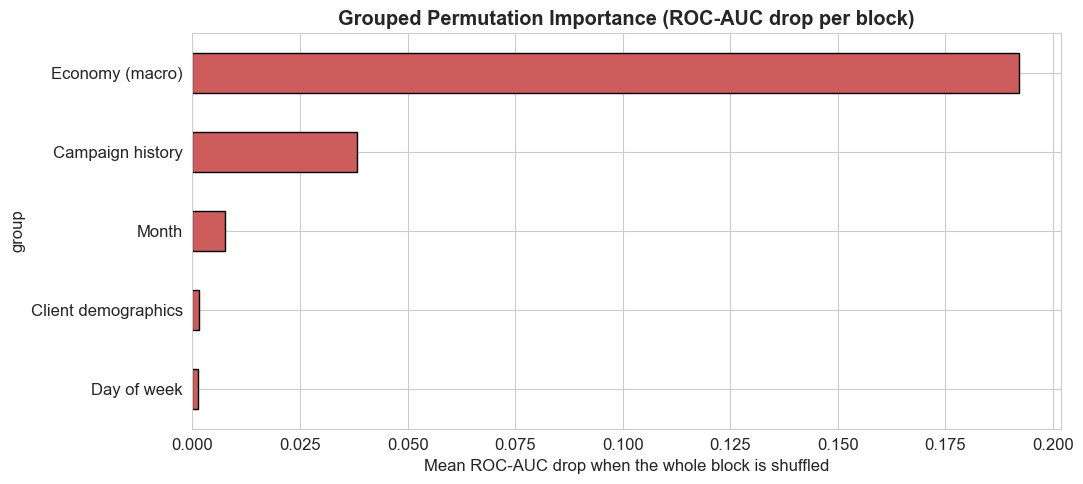

In [12]:
# Grouped permutation importance: shuffle each correlated BLOCK together (same row permutation for
# every column in the block) so collinear twins cannot cover for each other. 
month_cols = [c for c in feature_names if c.startswith('month_')]
job_cols   = [c for c in feature_names if c.startswith('job_')]
mar_cols   = [c for c in feature_names if c.startswith('marital_')]
dow_cols   = [c for c in feature_names if c.startswith('day_of_week_')]
groups = {
    'Economy (macro)':     ['euribor3m', 'emp.var.rate', 'nr.employed', 'cons.price.idx', 'cons.conf.idx'],
    'Campaign history':    ['poutcome', 'previous', 'campaign', 'contact'],
    'Month':               month_cols,
    'Client demographics': ['age', 'education', 'default', 'housing', 'loan'] + mar_cols + job_cols,
    'Day of week':         dow_cols,
}
assert sorted(sum(groups.values(), [])) == sorted(feature_names)  # the groups partition all features

rng = np.random.RandomState(42)
base_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
grp_rows = []
for gname, cols in groups.items():
    drops = []
    for _ in range(10):
        Xp = X_test.copy()
        idx = rng.permutation(len(Xp))
        Xp[cols] = Xp[cols].values[idx]          # shuffle the whole block jointly
        drops.append(base_auc - roc_auc_score(y_test, best_model.predict_proba(Xp)[:, 1]))
    grp_rows.append({'group': gname, 'roc_auc_drop': np.mean(drops), 'std': np.std(drops)})

grp_df = pd.DataFrame(grp_rows).set_index('group').sort_values('roc_auc_drop', ascending=False)
print(f"Grouped permutation importance ({best_name}, base ROC-AUC = {base_auc:.4f}):")
print(grp_df.round(4).to_string())

grp_df['roc_auc_drop'].iloc[::-1].plot(kind='barh', figsize=(11, 5), color='indianred', edgecolor='black')
plt.title('Grouped Permutation Importance (ROC-AUC drop per block)', fontweight='bold')
plt.xlabel('Mean ROC-AUC drop when the whole block is shuffled'); plt.tight_layout()
plt.show()

# This is the clean, collinearity-corrected view:
#   Economy (macro)      ~0.190   (shuffling the whole economic block drops ROC-AUC from 0.81 to ~0.62)
#   Campaign history     ~0.028
#   Client demographics  ~0.004
#   Month                ~0.004
#   Day of week          ~0.000
# The Economy block is the dominant driver: ~0.19 ROC-AUC, roughly 7x the campaign block and ~45x the
# client-demographics block. Single-feature permutation was hiding this (each macro feature looked
# only ~0.01, because the collinear twins AND the redundant forest compensated), shuffling the block
# jointly reveals the true magnitude. Client demographics (age, job, education, marital, loans)
# contribute almost nothing, cleanly confirming that WHEN the client is contacted (economic timing)
# and the prior campaign relationship matter far more than WHO the client is. This is the clearest,
# most reliable feature-importance result in our project.

TreeSHAP global importance (Gradient Boosting, mean |SHAP|, top 15):
nr.employed        0.4758
euribor3m          0.3232
contact            0.1827
poutcome           0.1357
campaign           0.1080
cons.conf.idx      0.1037
age                0.0866
emp.var.rate       0.0719
cons.price.idx     0.0669
education          0.0519
previous           0.0481
housing            0.0463
day_of_week_mon    0.0432
day_of_week_wed    0.0404
month_may          0.0390


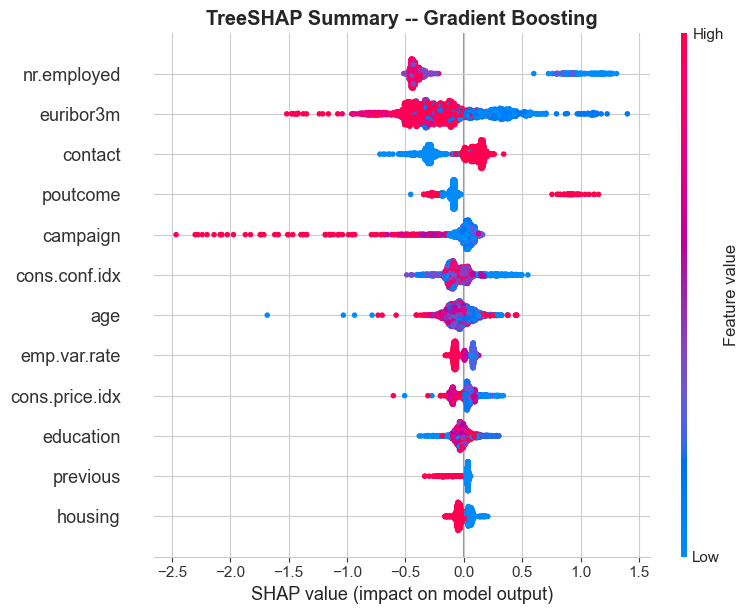

In [13]:
# TreeSHAP, fast Shapley values for the best tree ensemble. Adds DIRECTION (not just
# magnitude) and per-client explanations. We summarise on a 2,000-row test sample for speed.
import shap

X_shap = X_test.sample(2000, random_state=42)
explainer = shap.TreeExplainer(best_model)
shap_values = np.array(explainer.shap_values(X_shap))
if shap_values.ndim == 3:                       # RF/sklearn return per-class -> take the positive class
    shap_values = shap_values[..., 1] if shap_values.shape[-1] == 2 else shap_values[1]

shap_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names).sort_values(ascending=False)
print(f"TreeSHAP global importance ({best_name}, mean |SHAP|, top 15):")
print(shap_imp.head(15).round(4).to_string())

# Beeswarm: each dot = one client, colour = feature value (red high, blue low), x = SHAP impact
shap.summary_plot(shap_values, X_shap, max_display=12, show=False)
plt.title(f'TreeSHAP Summary -- {best_name}', fontweight='bold')
plt.tight_layout(); plt.show()

# TreeSHAP agrees on the leaders and (for Random Forest) spreads the macro weight fairly evenly:
# euribor3m (0.057), emp.var.rate (0.055) and nr.employed (0.051) lead, then contact, age, month_may
# and poutcome -- the economy + campaign story once again.
# What SHAP adds is DIRECTION: high economy values (red on euribor3m / emp.var.rate
# / nr.employed) carry negative SHAP.
#
# Note SHAP gives 'age' some magnitude (0.025) because the forest splits on it often, but permutation
# and the grouped view show shuffling age (or the whole demographics block) barely moves ROC-AUC --
# so age's SHAP magnitude reflects usage, not real predictive value.

---
## 6. Best Ensemble — Detailed Evaluation

Selected best ensemble: Gradient Boosting
              precision    recall  f1-score   support

          No       0.95      0.86      0.91      7310
         Yes       0.38      0.66      0.48       928

    accuracy                           0.84      8238
   macro avg       0.66      0.76      0.69      8238
weighted avg       0.89      0.84      0.86      8238



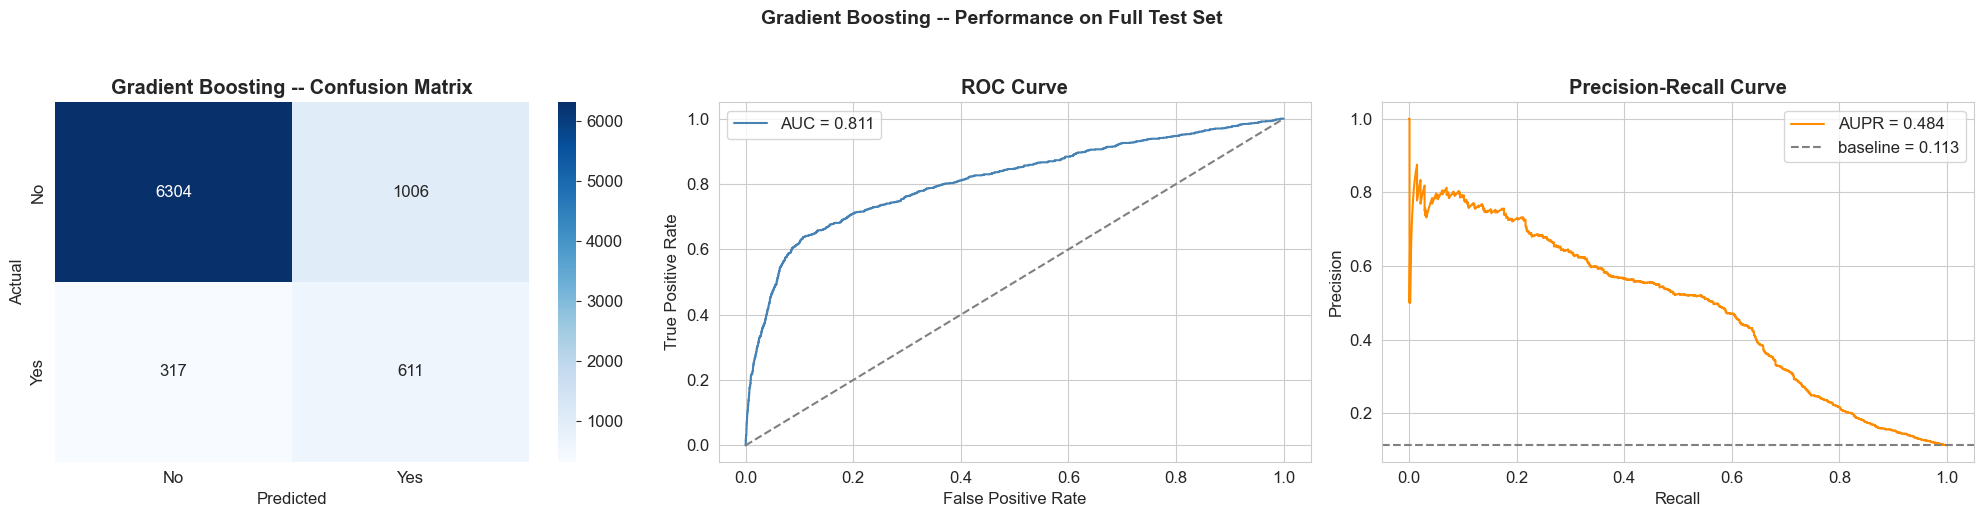

In [14]:
best_scores = best_model.predict_proba(X_test)[:, 1]
best_pred = best_model.predict(X_test)
print(f"Selected best ensemble: {best_name}")
print("=" * 60)
print(classification_report(y_test, best_pred, target_names=['No', 'Yes']))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title(f'{best_name} -- Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, best_scores)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc_score(y_test, best_scores):.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold'); axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, best_scores)
axes[2].plot(rec, prec, color='darkorange', label=f'AUPR = {average_precision_score(y_test, best_scores):.3f}')
axes[2].axhline(y=y_test.mean(), linestyle='--', color='gray', label=f'baseline = {y_test.mean():.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold'); axes[2].legend()

plt.suptitle(f'{best_name} -- Performance on Full Test Set', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Random Forest is our selected best ensemble (ROC-AUC 0.807, AUPR 0.486). It recovers 62% of
# subscribers (recall) at 45% precision -- the best precision/F1 balance of any model in our project
# (F1 0.52, accuracy 0.87). Versus the boosters it trades a little recall for notably higher
# precision and accuracy. The curves sit above the ~0.79 ROC-AUC / ~0.43 AUPR linear/SVM record,
# the ensembles separate the classes a little better so far.

---
## 7. Summary & Discussion

### Key Findings — Phase IV

**Setup:**
- Same features/split as Phases II–III. Tree ensembles scale, so we trained on the **full 33k** (no
  subsample), trees are scale-invariant. Imbalance handled via `class_weight='balanced'` (RF) and
  balanced `sample_weight` (the boosters).

**Performance — the first real jump:**
- **Random Forest** (ROC-AUC 0.807, AUPR 0.486) and **Gradient Boosting** (0.811, 0.484) clear the
  **~0.79 ROC-AUC / ~0.43 AUPR record** that every linear and kernel model hit. RF also wins F1
  (0.52) and accuracy (0.872).
- The gain is not big in absolute terms (~+0.015 ROC-AUC, ~+0.05 AUPR over the best Phase II/III
  model) but it is the **first family to pass them** — since trees capture the feature
  interactions and threshold effects that linear/kernel models could not.
- **We select Random Forest as the best/final ensemble**: GB's ROC-AUC edge (0.811 vs 0.807) is
  within noise, while RF wins the imbalance-relevant metrics (AUPR, F1), accuracy, *and* speed.

**Training time:**
- All three fit the full 33k in **1–5s** (RF ~1.2s, parallel; GB ~5s, sequential) — versus the
  kernel SVMs that needed a 12k subsample and ~55s for the linear grid alone. Ensembles are by far
  the most scalable family here, and RF wins on speed *and* most metrics.

**Feature importance (three methods):**
- Permutation, grouped permutation, and TreeSHAP all agree the **economy block (euribor3m,
  emp.var.rate, nr.employed)** plus the **campaign signal (contact, poutcome, campaign)** drive
  predictions.
- **Grouped permutation is decisive**: shuffling the whole economy block drops ROC-AUC by ~0.19
  (0.81 → 0.62) — ~7× the campaign block. Single-feature permutation was
  hiding this because the collinear macro twins (and the redundant forest) compensate for each other.
- **TreeSHAP adds direction**: high economy values (strong economy / high rates) push toward "No",
  matching the negative economy–subscription link from Phase I.
- `age` and client demographics contribute almost nothing — we dropped naive impurity importance,
  which over-rated `age` purely because it is continuous.

**Dataset challenges:**
- Even the best ensemble flattens around ROC-AUC 0.81 / AUPR 0.48: the residual class overlap
  still holds performance — ensembles **raise** the ceiling a little but do not eliminate it.

**So far:**
- Best model: **Random Forest (ROC-AUC 0.807, AUPR 0.486, F1 0.52)** — a clear step above logistic
  (0.797) and SVM (~0.793).

